<a href="https://colab.research.google.com/github/AqsaAamena/Basic-Python-Projects/blob/main/Housing_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.kaggle.com/datasets/hamzamarral/california-housing-dataset

Q2. (Dataset Selection & Initial Exploration)
Load the dataset and show first 10 rows.
Write 5-6 lines explaining why you chose this dataset and what continuous
value you want to predict.

In [19]:
import pandas as pd


In [20]:
df= pd.read_csv("housing.csv")
df.head(10)

#-----Reason to choose housing dataset-------
#I selected the California Housing dataset.
#The target variable is Median House Value, which is a continuous number because house prices can take many different values.
#The dataset also includes features like median income, average house age, number of rooms, and location (latitude and longitude).
#This makes it a good choice for regression tasks where the goal is to predict house prices.
#This makes it a realistic dataset for regression tasks, where the goal is to predict house prices.

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


Q3. (Missing & Duplicate Values Analysis)
Check for missing values in each column and calculate their percentage.
Handle missing values appropriately (drop or fill).
Check and remove duplicate rows if any.
Write your observations and steps taken.

In [ ]:
# 1. Calculate missing values and their percentages FIRST
missing_val = df.isnull().sum()
missing_val_percent = (missing_val / len(df)) * 100

print("Missing values percentage in each column:")
print(missing_val_percent)
print("shape before modify:-",df.shape)

# 2. Handle missing values (dropping rows with missing values)
if missing_val.sum() > 0:
    df.dropna(inplace=True)  # This actually removes them from your dataset df
    print(f"\nSuccessfully dropped rows with missing values. New shape: {df.shape}")
else:
    print("\nNo missing values found!.")

# 3. Check and remove duplicate rows if any
dup_rows = df.duplicated().sum()
if dup_rows > 0:
    df.drop_duplicates(inplace=True)
    print(f"Dropped {dup_rows} duplicate rows.")
else:
    print("No duplicate rows found!")
#Missing Value Analysis:
#I checked for missing values across all columns and calculated their percentages.

#Handling Missing Values:
#Since the missing values accounted for a very small fraction of the data,
#I handled them by dropping the rows using df.dropna(inplace=True).
#This reduced the dataset from 20,640 rows to 20,433 rows.

#Duplicate Check:
#I checked for duplicate rows using df.duplicated().sum().

Missing values percentage in each column:
longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64
shape before modify:- (20640, 10)

Successfully dropped rows with missing values. New shape: (20433, 10)
No duplicate rows found!


Q4. (Statistical Summary)
Use describe() to generate statistical summary of numeric columns.
Identify min, max, mean, and median of the target variable.
Write at least 4 meaningful observations about the data distribution.

In [ ]:
# Identify min, max, mean, and median of the target variable (median_house_value)
target_var= df['median_house_value'].describe()
print("Target Variable (median_house_value) Statistics:")
print(f"- Minimum: ${target_var['min']:,.2f}")
print(f"- Maximum: ${target_var['max']:,.2f}")
print(f"- Mean (Average): ${target_var['mean']:,.2f}")
print(f"- Median (50%): ${target_var['50%']:,.2f}")

#------------------Observations-------------------#
#The maximum house value is exactly $500,001, which strongly suggests the data is artificially capped at $500k.
#For columns like total_rooms and total_bedrooms, the mean is much higher than the median (50%).
#The median_income ranges from 0.5 to 15.0 with a median of 3.5
#The housing_median_age has a mean of ~28.6 and a median of 29.0. Because these two values are almost identical

Target Variable (median_house_value) Statistics:
- Minimum: $14,999.00
- Maximum: $500,001.00
- Mean (Average): $206,864.41
- Median (50%): $179,700.00


Q5. (Histogram Analysis of Numeric Features)
Plot histograms for all important numeric columns (including the target
variable).
Write detailed insights for each plot.

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

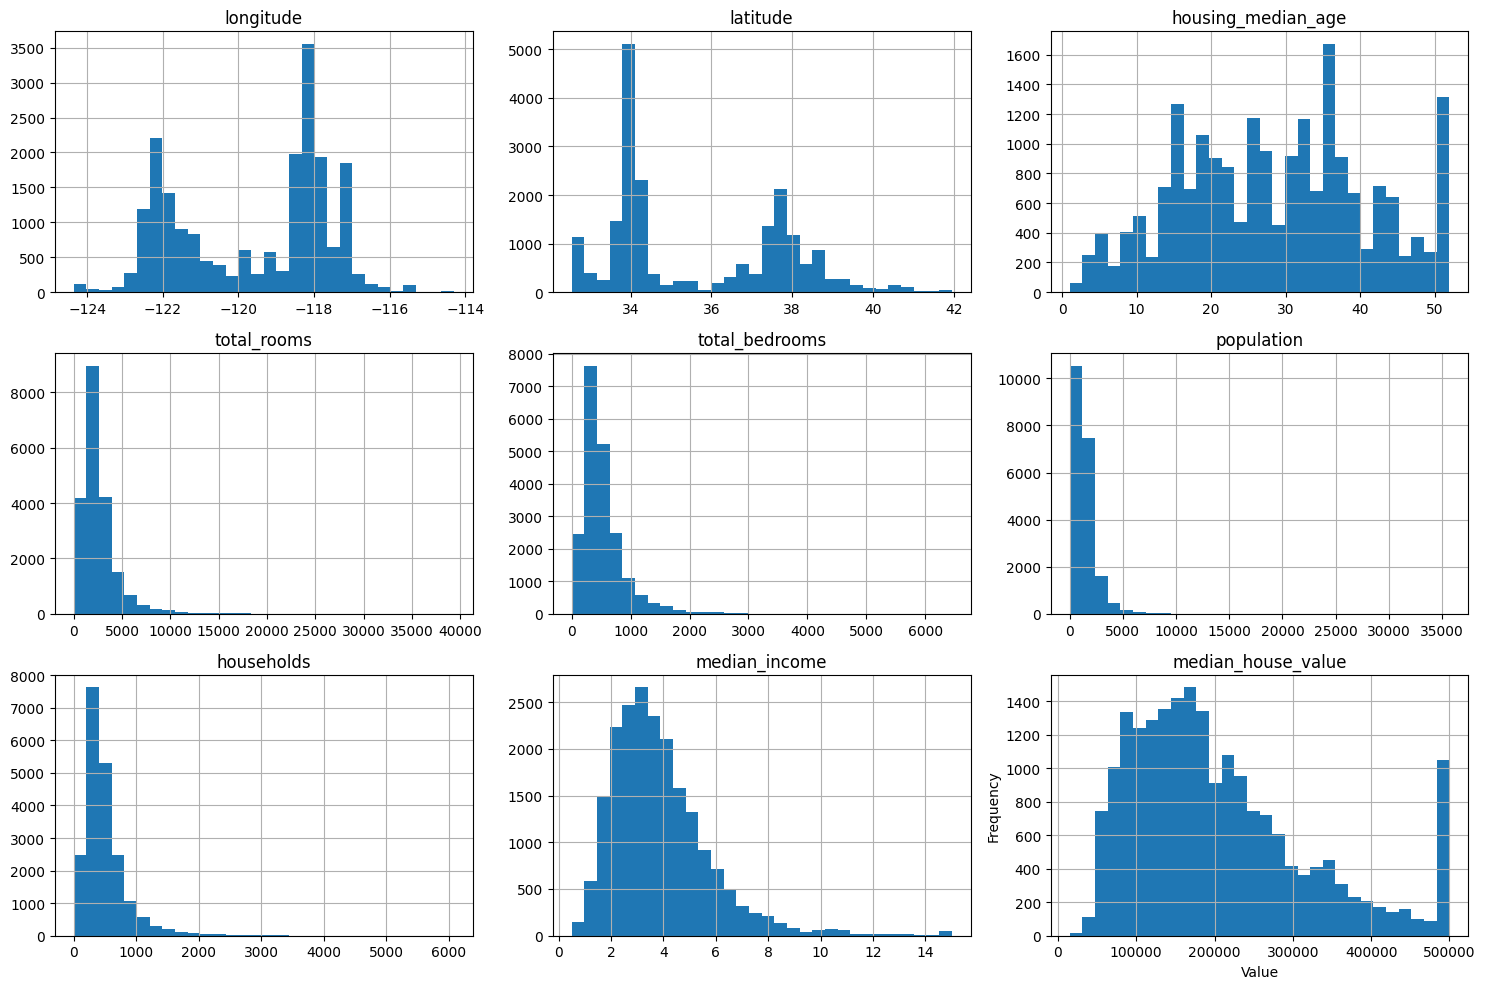

In [ ]:
# Plot histograms for all important numeric columns
df.hist(bins=30, figsize=(15,10))
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

#-----------Detailed Insights-----------
#median_house_value (Target): Shows a clear spike at the very far right ($500,000), confirming the data cap outlier issue.
#housing_median_age: Has a relatively uniform/balanced distribution, though there is a small spike around 52 years.
#total_rooms, total_bedrooms, population, households: These plots look almost identical—highly right-skewed with long tails,
#meaning most neighborhoods are small-to-medium sized, while a few are massive outliers.
#median_income: Follows a neat unimodal, slightly right-skewed distribution, peaking around 3 to 4.

Q6. (Count Plots of Categorical Features)
Identify categorical columns in your dataset.
Create count plots for all categorical features using seaborn.
Analyze the distribution and write business/domain-related insights.

Categorical Columns in Dataset: Index(['ocean_proximity'], dtype='object')


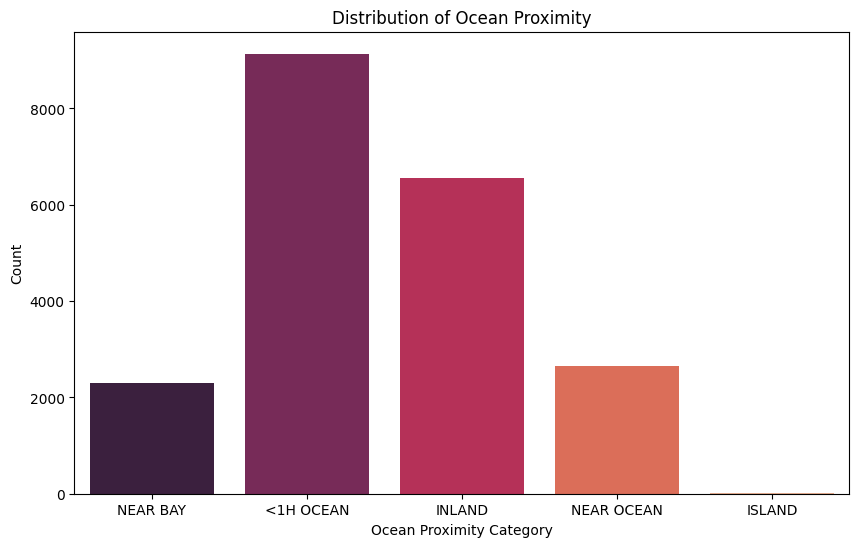

In [ ]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"Categorical Columns in Dataset: {categorical_cols}")

# Create the count plot using seaborn
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='ocean_proximity', hue=df['ocean_proximity'],palette='rocket')
plt.title('Distribution of Ocean Proximity')
plt.xlabel('Ocean Proximity Category')
plt.ylabel('Count')
plt.show()

#--------business and domain-related insights----------
#Dominant Market Categories: The vast majority of properties in this dataset are classified as <1H OCEAN (less than an hour from the ocean) or INLAND.
#Premium/Scarcity Value: Properties categorized as ISLAND are extremely rare (almost invisible on the plot), followed by NEAR OCEAN and NEAR BAY.
#Market Segmentation: Real estate developers or marketers can divide this data into two primary markets:
# high-volume, more affordable inland options, versus premium-priced coastal/near-water options.

Q7. (Correlation Heatmap)
Create a correlation heatmap for all numeric features.
Highlight which features are strongly correlated with the target variable.
Write your observations regarding feature relationships.

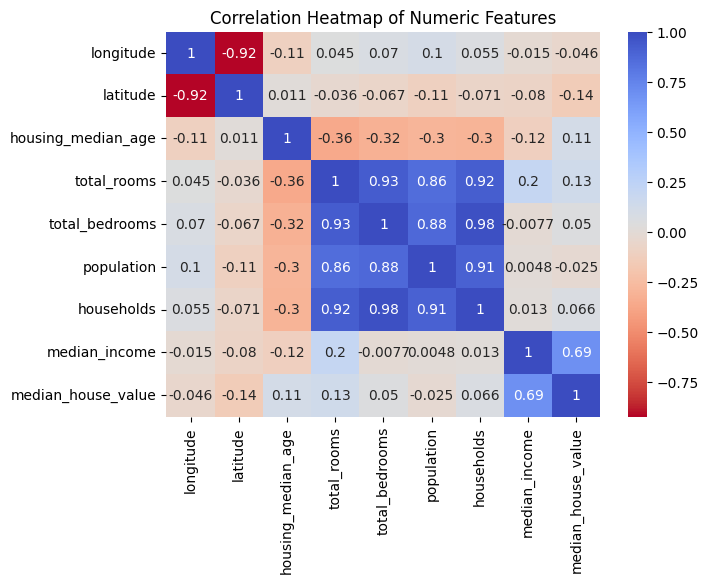


Correlation of features with target variable (median_house_value):
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


In [ ]:
# Select only numeric columns to calculate correlation
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

# Plot the correlation heatmap using seaborn
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm_r')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

# Print correlation of all features with the target variable
print("\nCorrelation of features with target variable (median_house_value):")
print(corr_matrix['median_house_value'].sort_values(ascending=False))

Q9. (Encoding Categorical Variables) Convert all categorical columns to numeric
form using suitable encoding techniques (One-Hot Encoding).
Show before and after transformation for at least two columns.
Explain your encoding choices.

In [30]:
#Show the data before encoding
print("--- BEFORE ENCODING ---")
print(df[['ocean_proximity', 'median_house_value']].head(5))

#Apply One-Hot Encoding to the categorical 'ocean_proximity' column
# We use drop_first=True to avoid dummy variable trap, or False if you want to keep all categories visible
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], dtype=int)

#Show the data after encoding
print("\n--- AFTER ENCODING ---")
# Displaying a few of the newly created one-hot columns
encoded_cols = [col for col in df_encoded.columns if 'ocean_proximity' in col]
print(df_encoded[['median_house_value'] + encoded_cols].head(5))

# Explaination for my choice Machine learning models only understand numbers,
# not text. One-hot encoding creates a new column for each category(like
# ocean_proximity_INLAND, ocean_proximity_NEAR BAY, etc.) and uses 1 to
# represent "Yes" and 0 to represent "No".


--- BEFORE ENCODING ---
  ocean_proximity  median_house_value
0        NEAR BAY            452600.0
1        NEAR BAY            358500.0
2        NEAR BAY            352100.0
3        NEAR BAY            341300.0
4        NEAR BAY            342200.0

--- AFTER ENCODING ---
   median_house_value  ocean_proximity_<1H OCEAN  ocean_proximity_INLAND  \
0            452600.0                          0                       0   
1            358500.0                          0                       0   
2            352100.0                          0                       0   
3            341300.0                          0                       0   
4            342200.0                          0                       0   

   ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  \
0                       0                         1   
1                       0                         1   
2                       0                         1   
3                       0                      

Q10. (Feature Scaling) Apply Standard Scaling on the independent features using
StandardScaler.
Show the first 5 rows of the scaled features.

In [36]:
from sklearn.preprocessing import StandardScaler

#Define the list of independent numeric features to scale
ind_feat = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
            'total_bedrooms', 'population', 'households', 'median_income']

#Initialize the StandardScaler
scaler = StandardScaler()

#Fit and transform the ACTUAL data inside those columns
df_encoded[ind_feat] = scaler.fit_transform(df_encoded[ind_feat])

#Show the first 5 rows of the scaled features
print(df_encoded[ind_feat].head(5))

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0  -1.327835  1.052548            0.982143    -0.804819       -0.970325   
1  -1.322844  1.043185           -0.607019     2.045890        1.348276   
2  -1.332827  1.038503            1.856182    -0.535746       -0.825561   
3  -1.337818  1.038503            1.856182    -0.624215       -0.718768   
4  -1.337818  1.038503            1.856182    -0.462404       -0.611974   

   population  households  median_income  
0   -0.974429   -0.977033       2.344766  
1    0.861439    1.669961       2.332238  
2   -0.820777   -0.843637       1.782699  
3   -0.766028   -0.733781       0.932968  
4   -0.759847   -0.629157      -0.012881  
